# PROJET RECHAUFFEMENT CLIMATIQUE

## Introduction

Au cours de ce projet, nous allons tester différentes fonctions afin de modéliser les variations climatiques à partir d'un jeu de données sous la forme d'un tableau de 2 colonnes: la première représente des jours, la seconde la température mesurée ce jour là à la station météorologique de Montélimar. À partir de ces données, nous allons de tenter de répondre à la problématique suivante : **Peut on mettre en évidence l'existence du réchauffement climatique en se basant *uniquement* sur le relevé quotidien de température en un endroit donné (Montélimar) ?**

Le dataset comporte 2 colonnes et 36295 lignes, correspondantes à 36295 jours. Cela représente environ un siècle.

## I. Affichage brute des températures

Dans un premier temps, nous affichons les données telles quelles.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [2]:
data = np.loadtxt('montelimar_temperature.dat')

jours = data[:, 0]
temp = data[:, 1]

date = (jours - jours[0]) / 365.25

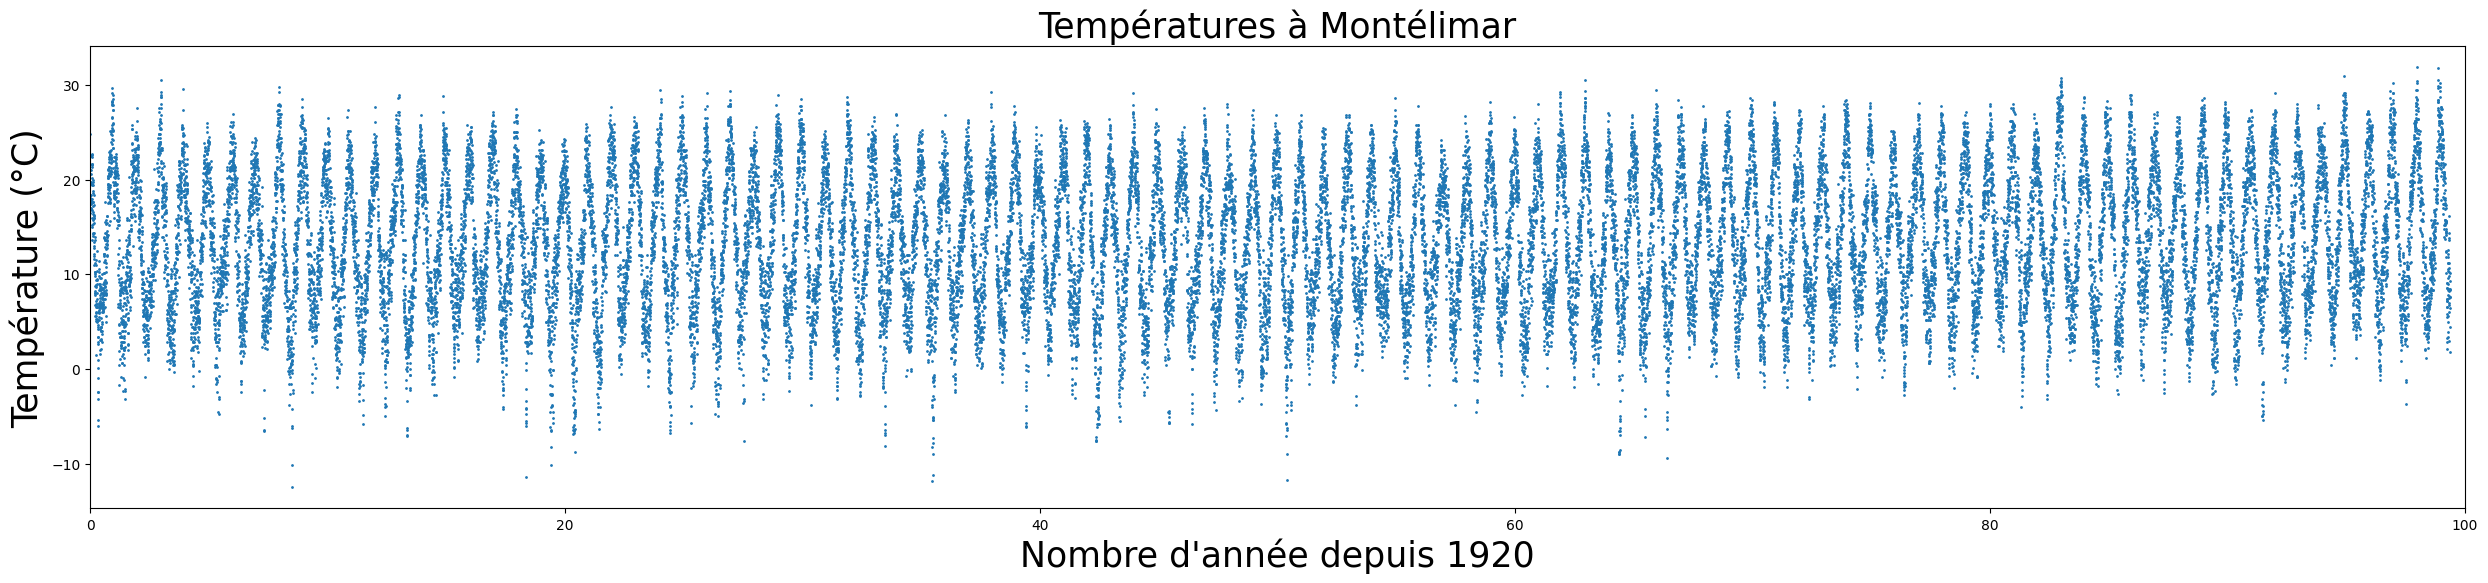

In [3]:
plt.figure(figsize=(10, 6))
plt.scatter(date, temp, s=1)
plt.title('Températures à Montélimar', fontsize = 25)
plt.xlabel("Nombre d'année depuis 1920", fontsize = 25)
plt.ylabel('Température (°C)', fontsize = 25)
plt.subplots_adjust(right=2.5)
plt.xlim(0, 100)
plt.show()

On voit bien que l'on ne peut tirer aucune conclusion de ce graphique. Qu’il s’agisse d’une période de 30 ans ou d’un siècle, il est difficile d'observer un quelconque effet ou changement signficatif de la température. En effet, la réchauffement est un effet faible et lent à l'échelle des données. Pour mettre en évidence une éventuelle hausse significative des températures, il est donc nécessaire de traiter les données différemment.

## II. Ajustement saisonnier

Pour représenter les variations saisonnières de la température, nous avons ajusté un modèle sinusoïdal de période un an sur l’ensemble des données allant de 1920 à 2020.
Utilisons un modèle sinusoïdale de type 

$$ T(t) = A \sin{(\omega t + \phi)} + B $$ 

où les paramètres $A$ (amplitude), $\phi$ (phase à l'origine des temps) et $B$ (température moyenne) sont les paramètres à ajuster aux données.

In [4]:
from scipy.optimize import curve_fit

In [5]:
def model_sin(t, A, phi, B):
    omega = 2 * np.pi # divisé par 1 an
    return A * np.sin(omega * t + phi) + B

In [6]:
sigma = 5.0

# Ajustement avec curve_fit
popt, pcov = curve_fit(model_sin, date, temp, sigma=sigma*np.ones_like(temp), absolute_sigma=True)
A_fit, phi_fit, B_fit = popt
perr = np.sqrt(np.diag(pcov))

Paramètres ajustés :
A = 9.01 ± 0.04
phi = 8.320 ± 0.004
B = 13.37 ± 0.03


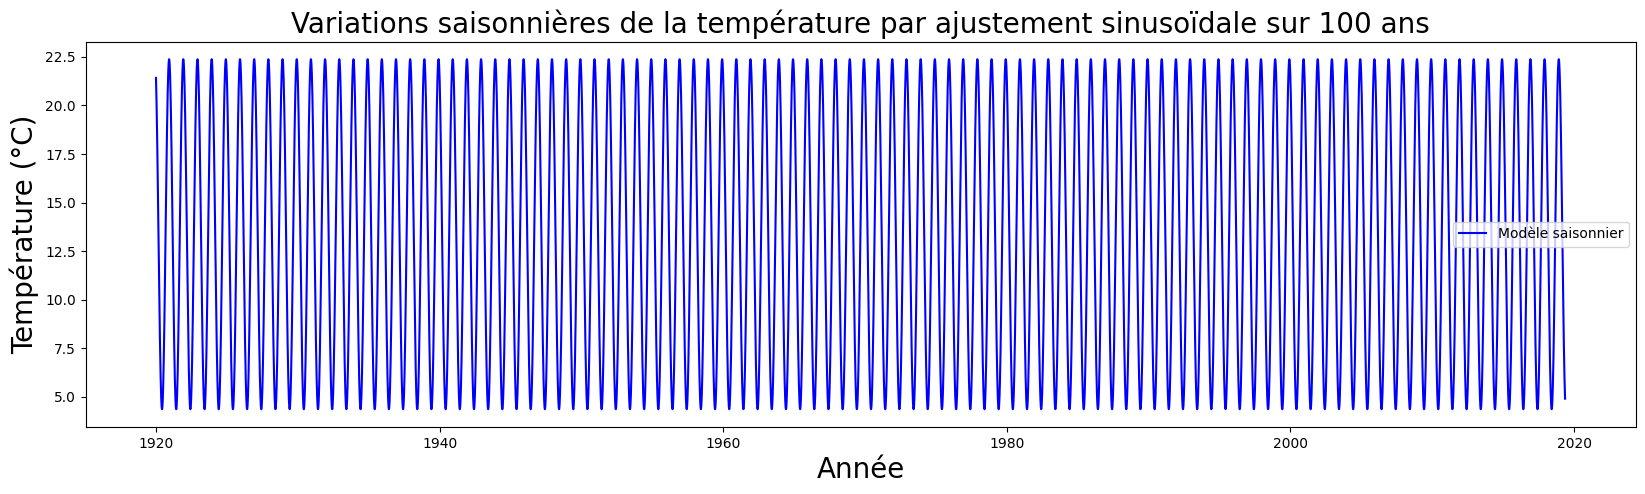

In [7]:
print("Paramètres ajustés :")
print(f"A = {A_fit:.2f} ± {perr[0]:.2f}")
print(f"phi = {phi_fit:.3f} ± {perr[1]:.3f}")
print(f"B = {B_fit:.2f} ± {perr[2]:.2f}")

t_fit = np.linspace(date.min(), date.max(), 10000)+1920

plt.figure(figsize=(20, 5))
plt.plot(t_fit, model_sin(t_fit, *popt), 'b-', label="Modèle saisonnier")

plt.xlabel("Année", fontsize = 20)
plt.ylabel("Température (°C)", fontsize = 20)
plt.title("Variations saisonnières de la température par ajustement sinusoïdale sur 100 ans", 
          fontsize = 20)
plt.legend()
plt.show()

Au vu des résultats, on remarque qu'un tel modèle ajusté sur l'ensemble des données ne met pas en évidence de hausse progressive de la température moyenne. Comme précédemment, nous n'observons pas d'effet significatif qui conduirait à une augmentation de la température.

## III. Ajustement sinusoïdale par décennie

Pour vérifier de manière plus précise s'il existe un réchauffement, nous pouvons refaire cet ajustement sinusoïdal par décennie depuis 1920. Ainsi, nous pourrons étudier l’évolution de la température moyenne $B$ sur des périodes plus courtes et étudier sa variation au fil des décennies.

In [8]:
#On découpe les données par décennie
decades = np.arange(0, 100, 10)
B_decades = []
B_errors = []
decade_centers = [] #On place chaque point correspond à chaque décennie au milieu de la décennie en question

In [9]:
for decade in decades:
    mask = (date >= decade) & (date < decade + 10)
    t_decade = date[mask]
    temp_decade = temp[mask]

    popt, pcov = curve_fit(model_sin, t_decade, temp_decade, sigma=5*np.ones_like(temp_decade), absolute_sigma=True)
    A_fit, phi_fit, B_fit = popt
    B_decades.append(B_fit)
    B_errors.append(np.sqrt(pcov[2, 2]))
    decade_centers.append(1920 + decade + 5)
    print(f"Décennie {1920+decade}-{1920+decade+9} : B = {B_fit:.2f} ± {np.sqrt(pcov[2,2]):.2f} °C")

Décennie 1920-1929 : B = 13.09 ± 0.08 °C
Décennie 1930-1939 : B = 12.86 ± 0.08 °C
Décennie 1940-1949 : B = 13.23 ± 0.08 °C
Décennie 1950-1959 : B = 12.95 ± 0.08 °C
Décennie 1960-1969 : B = 12.81 ± 0.08 °C
Décennie 1970-1979 : B = 12.72 ± 0.08 °C
Décennie 1980-1989 : B = 13.41 ± 0.08 °C
Décennie 1990-1999 : B = 13.82 ± 0.08 °C
Décennie 2000-2009 : B = 14.20 ± 0.08 °C
Décennie 2010-2019 : B = 14.66 ± 0.09 °C


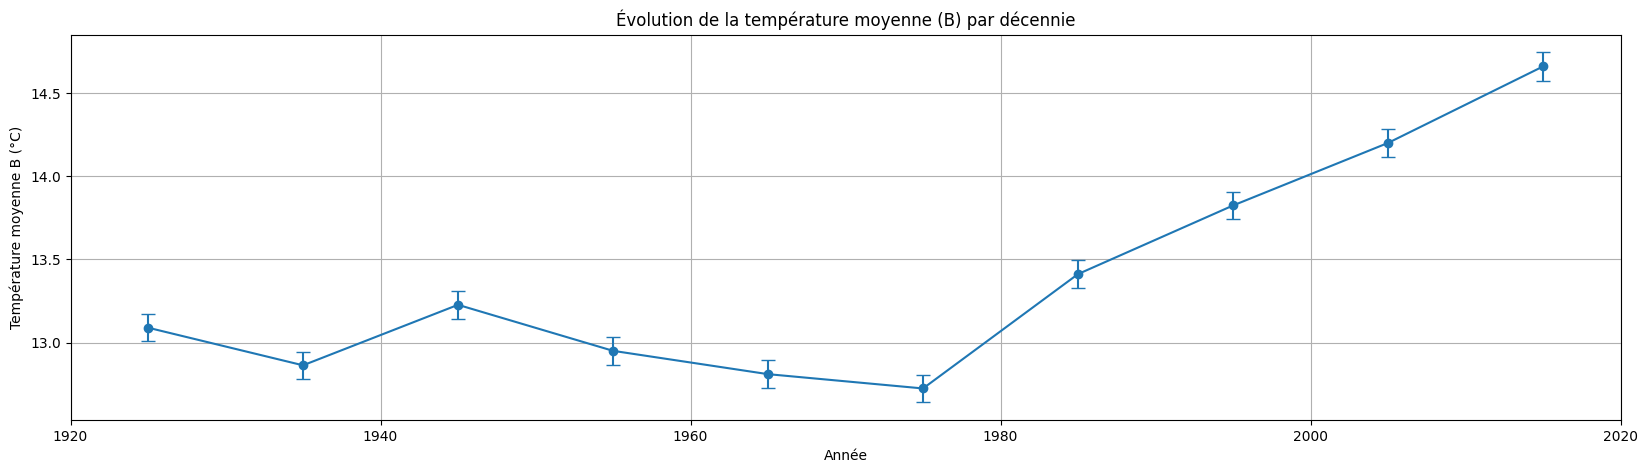

In [10]:
plt.figure(figsize=(20, 5))
plt.errorbar(decade_centers, B_decades, yerr=B_errors, fmt='o-', capsize=5)
plt.xlabel("Année")
plt.xlim(1920, 2020)
plt.ylabel("Température moyenne B (°C)")
plt.title("Évolution de la température moyenne (B) par décennie")
plt.grid()
plt.show()

En étudiant l’évolution de la température moyenne $B$ par décennie, on constate tout d’abord une fluctuation autour de 13°C entre 1920 et 1950. Puis il y a un léger déclin dans les années 1960 et 1970, avant qu’une forte hausse ne s’amorce à partir des années 1980. Sur le graphique, on voit clairement que cette augmentation se poursuit jusqu’en 2020, pour atteindre des valeurs supérieures à 14,5°C, soit plus de 2°C de plus par rapport aux niveaux les plus bas des années 1970.

**Malgré les marges des barres d'erreurs, on observe une tendance globale à la hausse. On constate donc effectivement une évolution de la température moyenne lors du dernier siècle et plus précisément, depuis les 4 dernières décennies**.

## IV. Accroissement linéaire de la température

Avec les résultats obtenus précédemment, on peut intuiter le fait que l'accroissement lent de la température suit un modèle linéaire. Nous pouvons alors compléter le modèle sinosoïdal par un terme linéaire ($C\times t$) pour chercher à se rendre compte d’un réchauffement progressif sur la période 1920–2020.

Utilisons un modèle de type:

$$ T(t) = A \sin{(\omega t + \phi)} + B + C t $$

où $C$ est un nouveau paramètre à ajuster, qui correspond à l'accroissement linéaire lent de la température.

Ajustons les paramètres sur la période du siècle entier dernier et voyons si nous observons un changement notable de la température avec ce modèle.

In [11]:
def model_sin2(t, A, phi, B, C):
    omega = 2 * np.pi
    return A * np.sin(omega * t + phi) + B + C * t

In [12]:
popt, pcov = curve_fit(model_sin2, date, temp, sigma=sigma*np.ones_like(temp), absolute_sigma=True)
A_fit, phi_fit, B_fit, C_fit = popt
perr = np.sqrt(np.diag(pcov))

In [13]:
print("Paramètres ajustés :")
print(f"A = {A_fit:.2f} ± {perr[0]:.2f}")
print(f"phi = {phi_fit:.3f} ± {perr[1]:.3f}")
print(f"B = {B_fit:.2f} ± {perr[2]:.2f}")
print(f"C = {C_fit:.3f} ± {perr[3]:.3f} °C/an soit un réchauffement de {C_fit*100:.2f} ± {perr[3]*100:.2f} °C depuis 100 ans.")

Paramètres ajustés :
A = 9.01 ± 0.04
phi = 8.320 ± 0.004
B = 12.53 ± 0.05
C = 0.017 ± 0.001 °C/an soit un réchauffement de 1.69 ± 0.09 °C depuis 100 ans.


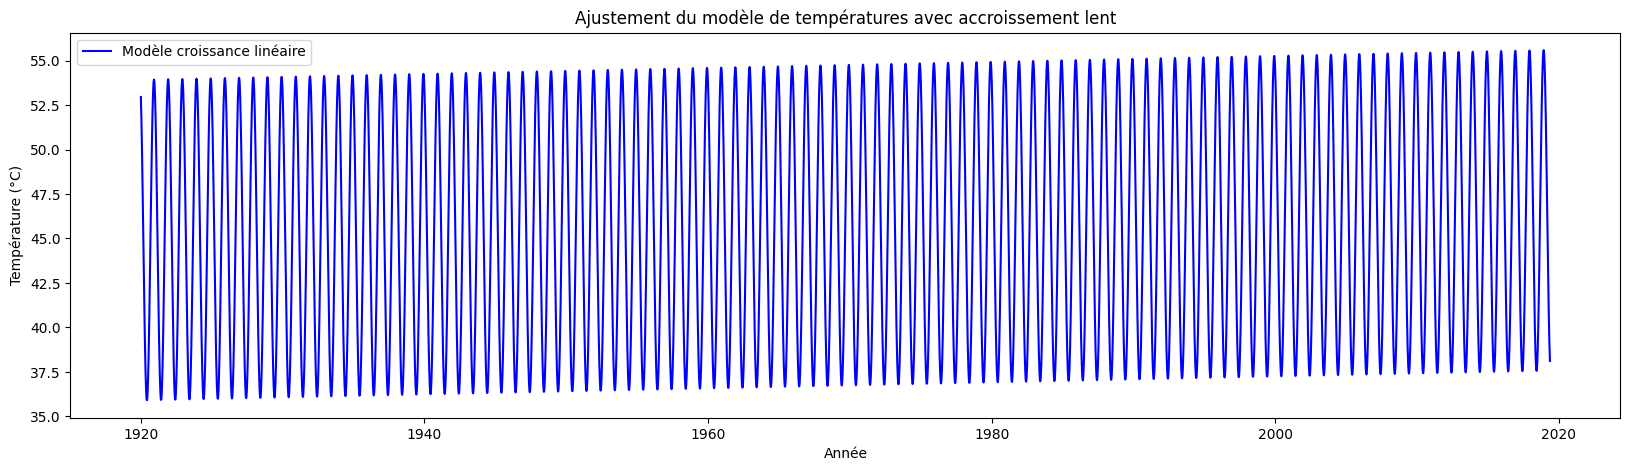

In [14]:
plt.figure(figsize=(20, 5))
t_fit = np.linspace(date.min(), date.max(), 10000)+1920
plt.plot(t_fit, model_sin2(t_fit, *popt), 'b', label="Modèle croissance linéaire")

plt.xlabel("Année")
plt.ylabel("Température (°C)")
plt.title("Ajustement du modèle de températures avec accroissement lent")
plt.legend()
plt.show()

Contrairement au modèle précédent sur une période d'un siècle, **on observe ici une augmentation progressive et modérée de la température**. En effet, il est manifeste qu'au fil des années, la température dérive lentement vers des valeurs plus élevées. 

Le coefficient $C$ révèle qu'entre 1920 et 2020, la température à Montélimar s'est accrue d'environ $1.7 ± 0.1$ °C. Sur le graphique, bien que la variation annuelle (d’une amplitude approximative de 9°C) soit la plus visible, la sinusoïde rouge s’élève progressivement à mesure que l’on approche de 2020. Cette élévation, bien que modeste d’une année à l’autre, s’accumule au fil du temps, corroborant l’idée d’un réchauffement linéaire et progressif.

Pour approfondir cette analyse, il serait pertinent de se concentrer sur les trente dernières années et d’examiner la pente linéaire obtenue sur cette période. Cela permettrait de déterminer si le réchauffement climatique s’est accéléré récemment ou s’il conserve un rythme constant.

In [15]:
popt, pcov = curve_fit(model_sin2, date[60:], temp[60:], 
                       sigma=sigma*np.ones_like(temp[60:]), absolute_sigma=True)
A_fit, phi_fit, B_fit, C_fit = popt
perr = np.sqrt(np.diag(pcov))

In [16]:
print("Paramètres ajustés :")
print(f"A = {A_fit:.2f} ± {perr[0]:.2f}")
print(f"phi = {phi_fit:.3f} ± {perr[1]:.3f}")
print(f"B = {B_fit:.2f} ± {perr[2]:.2f}")
print(f"C = {C_fit:.4f} ± {perr[3]:.4f} °C/an soit un réchauffement de {C_fit*30:.2f} ± {perr[3]*30:.2f} °C depuis 30 ans.")

Paramètres ajustés :
A = 9.01 ± 0.04
phi = 8.320 ± 0.004
B = 12.52 ± 0.05
C = 0.0170 ± 0.0009 °C/an soit un réchauffement de 0.51 ± 0.03 °C depuis 30 ans.


Selon ce second ajustement basé sur les 30 dernières années, le réchauffement observé à Montélimar ne atteint pas 1°C, comme les estimations moyennes mondiales, mais représente tout de même la moitié de cette valeur. Le coefficient linéaire $ C $ obtenu reste très proche de celui calculé sur une période de 100 ans, confirmant ainsi la tendance à une augmentation progressive de la température dans la région. Bien que cette hausse puisse sembler faible d’une année sur l’autre ($ C $ étant petit), elle devient significative sur le long terme et entraîne un impact notable après plusieurs décennies.

## Conclusion

Ainsi, nos analyses effectuées dans ce projet révèlent une augmentation marquée de la température moyenne à Montélimar au cours du dernier siècle, avec une accélération particulièrement notable depuis les années 1980. Depuis les années 1970, la température moyenne a grimpé de plus de 2°C, et de 1,7°C sur l’ensemble des 100 dernières années, illustrant un réchauffement significatif qui s’est intensifié ces dernières décennies.  

Par ailleurs, l’élévation linéaire de la température, mise en évidence par le terme $ C $ du modèle sinusoïdal, indique un processus lent et progressif, mais dont les effets deviennent considérables sur le long terme.

Enfin, les mesures locales ont clairement mis en évidence un réchauffement climatique significatif en accélération. Toutefois, il serait pertinent de reproduire cette étude sur d'autres stations météorologiques afin de valider ces résultats et d’évaluer l’ampleur globale de ce phénomène.